# 📊 Market Analysis — Round 1 (Days -2, -1, 0)

This notebook analyzes order book (prices) and trade data for two products:
- **ASH_COATED_OSMIUM**
- **INTARIAN_PEPPER_ROOT**

Sections:
1. Data Loading & Cleaning
2. Mid-Price History
3. Bid-Ask Spread Analysis
4. Order Book Depth & Volume
5. Trade Flow Analysis
6. Trade Price vs Mid-Price
7. Volatility & Rolling Stats
8. Summary Stats

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#444',
    'axes.labelcolor': '#ccc',
    'axes.titlecolor': '#fff',
    'xtick.color': '#aaa',
    'ytick.color': '#aaa',
    'text.color': '#ccc',
    'grid.color': '#2a2d3a',
    'grid.linestyle': '--',
    'grid.alpha': 0.6,
    'legend.facecolor': '#1a1d27',
    'legend.edgecolor': '#444',
    'figure.titlesize': 14,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
})

COLORS = {
    'ASH_COATED_OSMIUM': '#00c9ff',
    'INTARIAN_PEPPER_ROOT': '#ff6b6b',
    'bid': '#00e676',
    'ask': '#ff5252',
    'mid': '#ffd740',
    'trade': '#ce93d8',
}

DAYS = [-2, -1, 0]
DATA_PATH = 'Data\\ROUND1\\prices_round_1_day_{}.csv'
TRADE_PATH = 'Data\\ROUND1\\trades_round_1_day_{}.csv'

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Data Loading & Cleaning

In [ ]:
price_dfs, trade_dfs = [], []

for day in DAYS:
    p = pd.read_csv(DATA_PATH.format(day), sep=';')
    t = pd.read_csv(TRADE_PATH.format(day), sep=';')
    price_dfs.append(p)
    trade_dfs.append(t)

prices = pd.concat(price_dfs, ignore_index=True)
trades = pd.concat(trade_dfs, ignore_index=True)

# Derived columns
prices['spread'] = prices['ask_price_1'] - prices['bid_price_1']
prices['global_ts'] = prices['day'] * 1_000_000 + prices['timestamp']  # unique tick index
trades['global_ts'] = trades.get('day', 0) + trades['timestamp']  # trades don't have a day col

PRODUCTS = prices['product'].unique().tolist()

print(f'Prices: {prices.shape[0]:,} rows | Trades: {trades.shape[0]:,} rows')
print(f'Products: {PRODUCTS}')
print(f'Days in prices: {sorted(prices["day"].unique())}')
prices.head(100)

prices.loc[prices['product'] == 'INTARIAN_PEPPER_ROOT', prices['mid_price'] == 0]

Prices: 60,000 rows | Trades: 2,276 rows
Products: ['INTARIAN_PEPPER_ROOT', 'ASH_COATED_OSMIUM']
Days in prices: [np.int64(-2), np.int64(-1), np.int64(0)]


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,spread,global_ts
0,-2,0,INTARIAN_PEPPER_ROOT,9992.0,17.0,NaN,NaN,NaN,NaN,10005.0,9.0,10008.0,17.0,NaN,NaN,9998.5,0.0,13.0,-2000000
1,-2,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10010.0,25.0,NaN,NaN,NaN,NaN,10010.0,0.0,NaN,-2000000
2,-2,100,INTARIAN_PEPPER_ROOT,9995.0,11.0,9992.0,16.0,NaN,NaN,10006.0,11.0,10008.0,16.0,NaN,NaN,10000.5,0.0,11.0,-1999900
3,-2,100,ASH_COATED_OSMIUM,9992.0,15.0,NaN,NaN,NaN,NaN,10008.0,15.0,10011.0,20.0,NaN,NaN,10000.0,0.0,16.0,-1999900
4,-2,200,INTARIAN_PEPPER_ROOT,9995.0,12.0,NaN,NaN,NaN,NaN,10008.0,20.0,NaN,NaN,NaN,NaN,10001.5,0.0,13.0,-1999800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,-2,4700,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10013.0,11.0,10016.0,29.0,NaN,NaN,10013.0,0.0,NaN,-1995300
96,-2,4800,ASH_COATED_OSMIUM,9995.0,24.0,NaN,NaN,NaN,NaN,10007.0,3.0,10013.0,14.0,10016.0,24.0,10001.0,0.0,12.0,-1995200
97,-2,4800,INTARIAN_PEPPER_ROOT,9999.0,9.0,9997.0,17.0,NaN,NaN,10010.0,9.0,10013.0,17.0,NaN,NaN,10004.5,0.0,11.0,-1995200
98,-2,4900,ASH_COATED_OSMIUM,9997.0,15.0,9995.0,22.0,NaN,NaN,10013.0,15.0,10016.0,22.0,NaN,NaN,10005.0,0.0,16.0,-1995100


## 2. Mid-Price History (All Days)

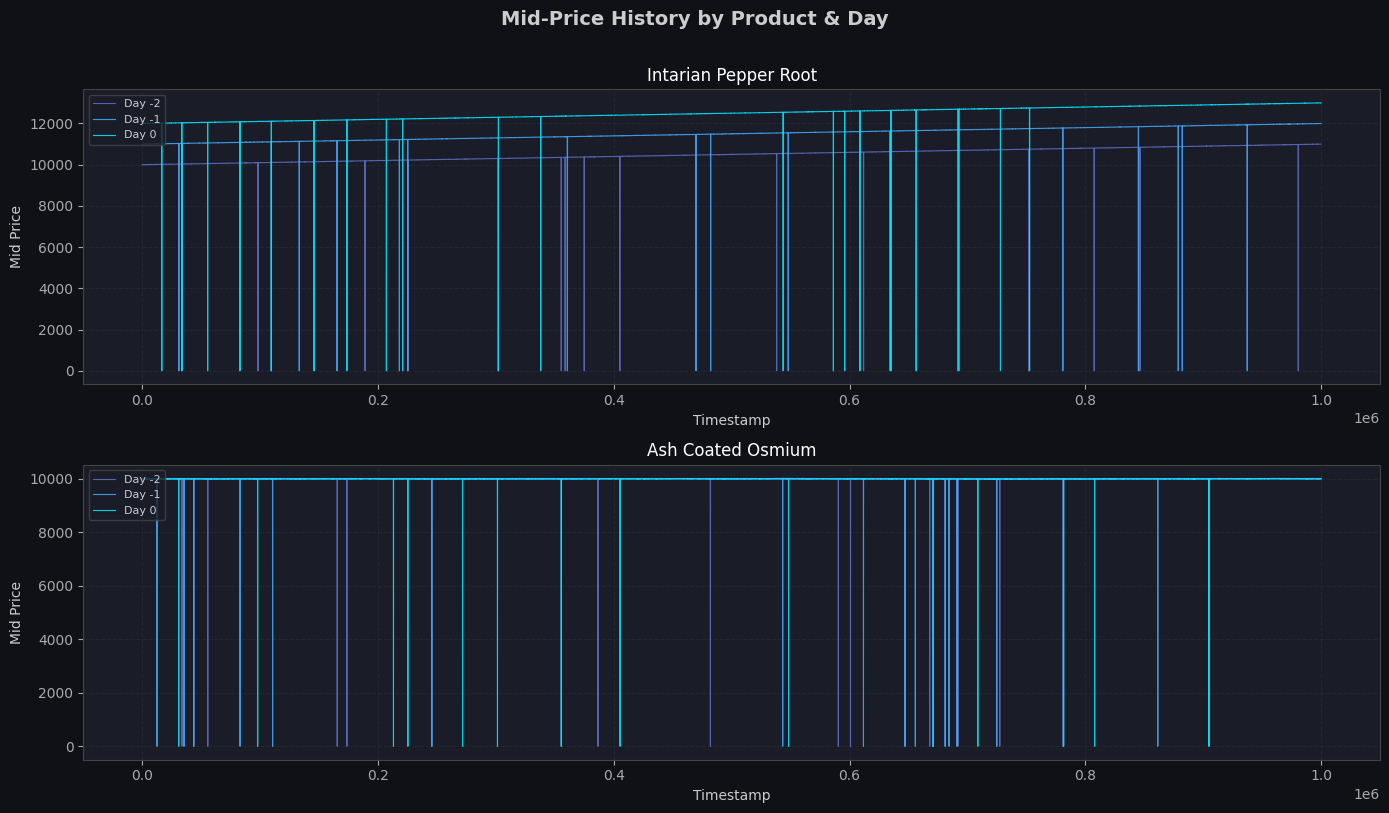

In [10]:
fig, axes = plt.subplots(len(PRODUCTS), 1, figsize=(14, 8), sharex=False)
fig.suptitle('Mid-Price History by Product & Day', fontsize=14, fontweight='bold', y=1.01)

day_colors = {-2: '#5c6bc0', -1: '#42a5f5', 0: '#00e5ff'}
day_labels = {-2: 'Day -2', -1: 'Day -1', 0: 'Day 0'}

for ax, product in zip(axes, PRODUCTS):
    sub = prices[prices['product'] == product]
    for day in DAYS:
        d = sub[sub['day'] == day].sort_values('timestamp')
        ax.plot(d['timestamp'], d['mid_price'],
                color=day_colors[day], lw=0.8, label=day_labels[day], alpha=0.9)
    ax.set_title(product.replace('_', ' ').title())
    ax.set_ylabel('Mid Price')
    ax.set_xlabel('Timestamp')
    ax.grid(True)
    ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('mid_price_history.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 3. Bid-Ask Spread Analysis

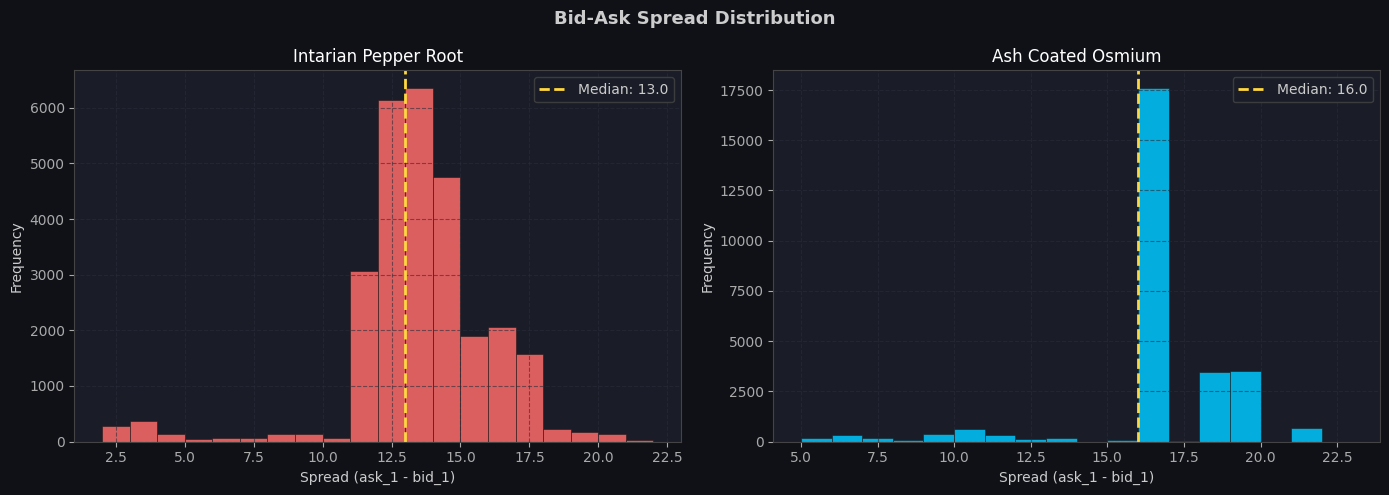

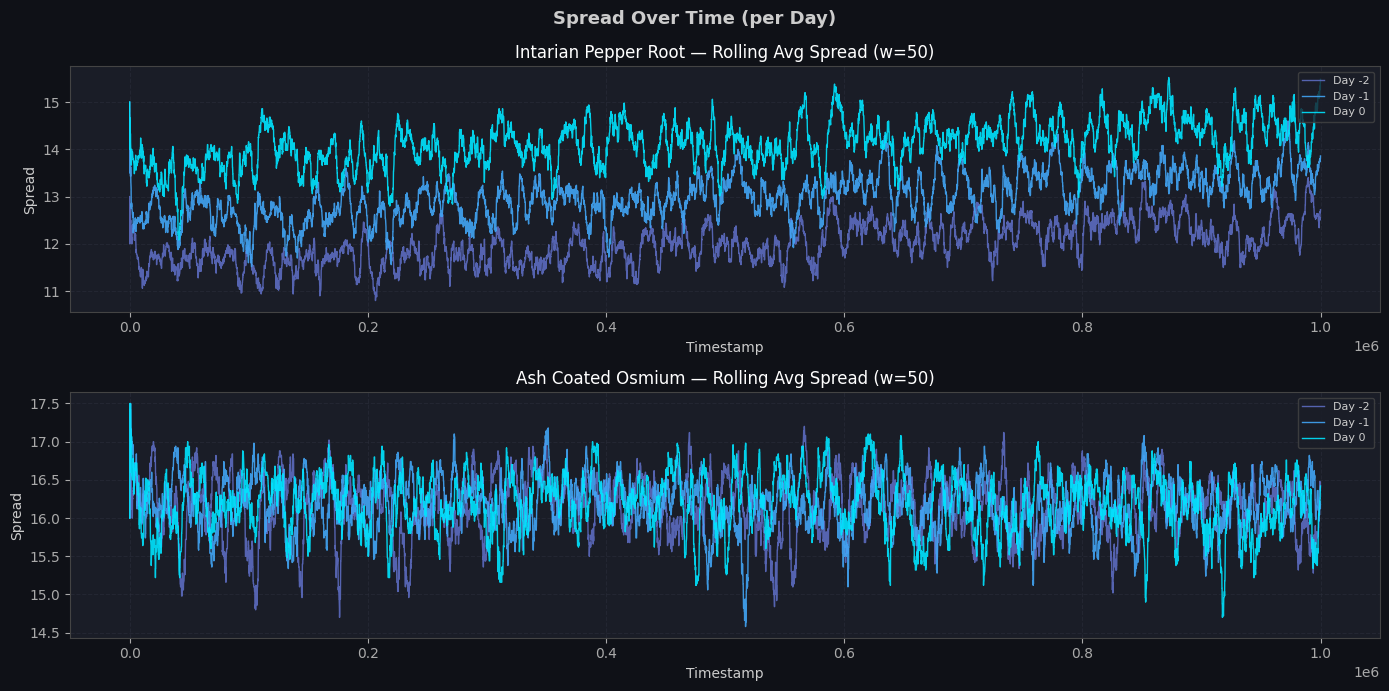

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bid-Ask Spread Distribution', fontsize=13, fontweight='bold')

for ax, product in zip(axes, PRODUCTS):
    sub = prices[(prices['product'] == product) & prices['spread'].notna()]
    color = COLORS[product]
    
    spread_vals = sub['spread']
    bins = range(int(spread_vals.min()), int(spread_vals.max()) + 2)
    ax.hist(spread_vals, bins=bins, color=color, alpha=0.85, edgecolor='#111', linewidth=0.4)
    
    med = spread_vals.median()
    ax.axvline(med, color='#ffd740', lw=2, linestyle='--', label=f'Median: {med:.1f}')
    ax.set_title(product.replace('_', ' ').title())
    ax.set_xlabel('Spread (ask_1 - bid_1)')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig('spread_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

# Spread over time (rolling)
fig, axes = plt.subplots(len(PRODUCTS), 1, figsize=(14, 7))
fig.suptitle('Spread Over Time (per Day)', fontsize=13, fontweight='bold')

for ax, product in zip(axes, PRODUCTS):
    sub = prices[(prices['product'] == product) & prices['spread'].notna()]
    color = COLORS[product]
    for day in DAYS:
        d = sub[sub['day'] == day].sort_values('timestamp')
        ax.plot(d['timestamp'], d['spread'].rolling(50, min_periods=1).mean(),
                color=day_colors[day], lw=1.0, label=day_labels[day], alpha=0.9)
    ax.set_title(f'{product.replace("_"," ").title()} — Rolling Avg Spread (w=50)')
    ax.set_ylabel('Spread')
    ax.set_xlabel('Timestamp')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True)

plt.tight_layout()
plt.savefig('spread_over_time.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 4. Order Book Depth & Volume

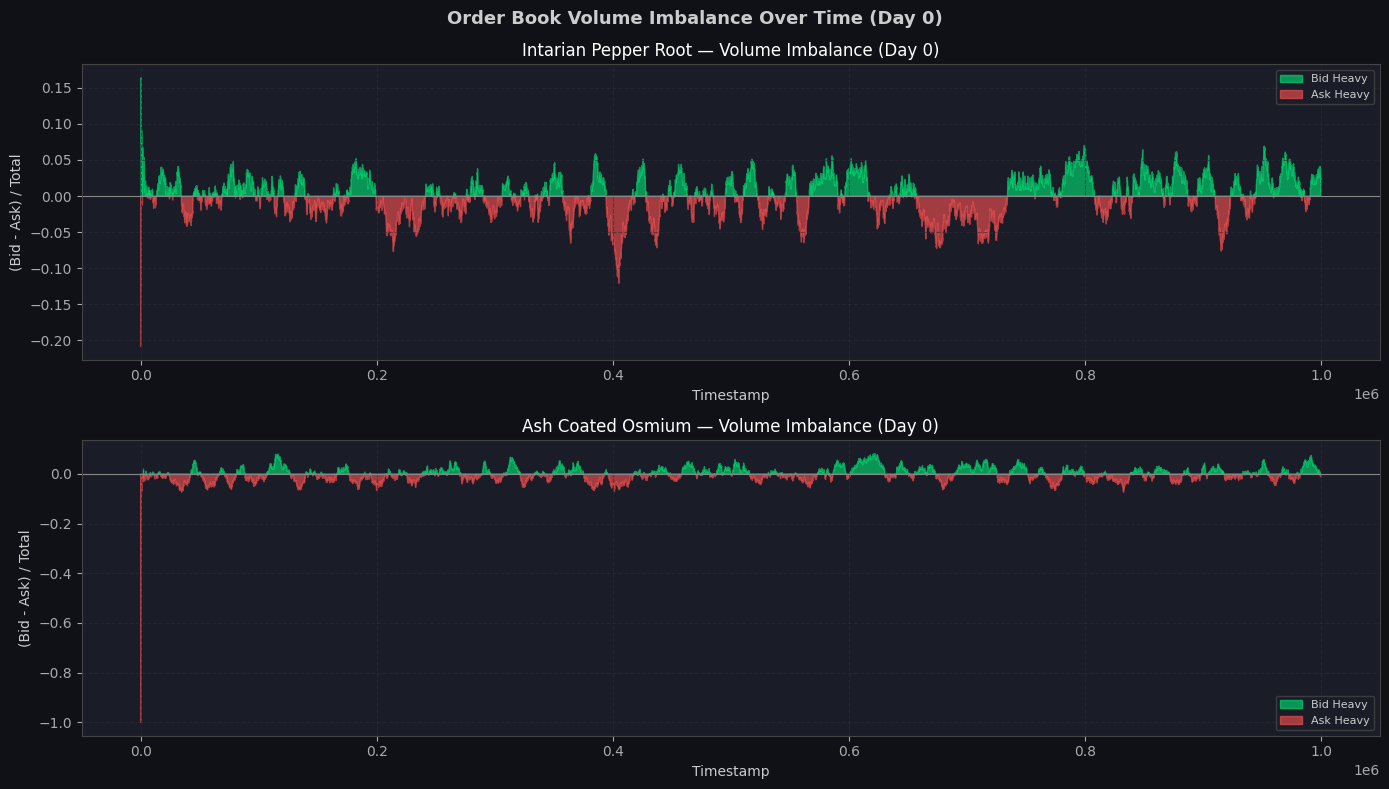

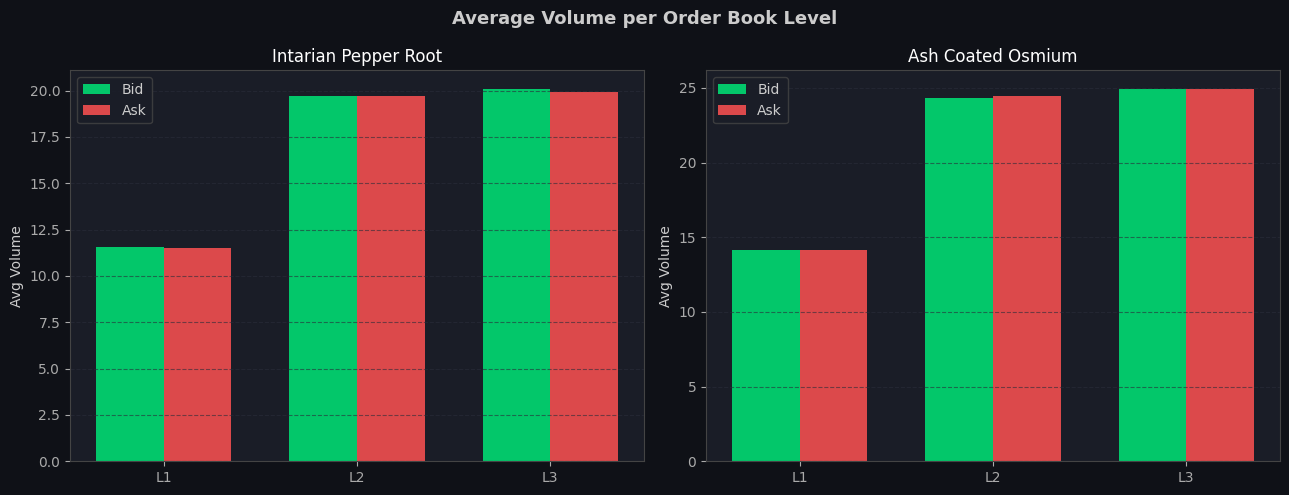

In [12]:
# Total available volume (all 3 levels) per tick
for side in ['bid', 'ask']:
    prices[f'{side}_total_vol'] = (
        prices[f'{side}_volume_1'].fillna(0) +
        prices[f'{side}_volume_2'].fillna(0) +
        prices[f'{side}_volume_3'].fillna(0)
    )

fig, axes = plt.subplots(len(PRODUCTS), 1, figsize=(14, 8))
fig.suptitle('Order Book Volume Imbalance Over Time (Day 0)', fontsize=13, fontweight='bold')

for ax, product in zip(axes, PRODUCTS):
    sub = prices[(prices['product'] == product) & (prices['day'] == 0)].sort_values('timestamp')
    
    roll_bid = sub['bid_total_vol'].rolling(100, min_periods=1).mean()
    roll_ask = sub['ask_total_vol'].rolling(100, min_periods=1).mean()
    imbalance = (roll_bid - roll_ask) / (roll_bid + roll_ask + 1e-9)
    
    ax.fill_between(sub['timestamp'], imbalance, 0,
                    where=imbalance >= 0, color='#00e676', alpha=0.6, label='Bid Heavy')
    ax.fill_between(sub['timestamp'], imbalance, 0,
                    where=imbalance < 0, color='#ff5252', alpha=0.6, label='Ask Heavy')
    ax.axhline(0, color='#888', lw=0.8)
    ax.set_title(f'{product.replace("_"," ").title()} — Volume Imbalance (Day 0)')
    ax.set_ylabel('(Bid - Ask) / Total')
    ax.set_xlabel('Timestamp')
    ax.legend(fontsize=8)
    ax.grid(True)

plt.tight_layout()
plt.savefig('volume_imbalance.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

# Avg volume by level
vol_cols = [f'{side}_volume_{lvl}' for side in ['bid','ask'] for lvl in [1,2,3]]
vol_avgs = prices.groupby('product')[vol_cols].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Average Volume per Order Book Level', fontsize=13, fontweight='bold')

for ax, product in zip(axes, PRODUCTS):
    row = vol_avgs.loc[product]
    levels = ['L1','L2','L3']
    bid_vals = [row[f'bid_volume_{i}'] for i in [1,2,3]]
    ask_vals = [row[f'ask_volume_{i}'] for i in [1,2,3]]
    
    x = np.arange(3)
    w = 0.35
    ax.bar(x - w/2, bid_vals, w, label='Bid', color='#00e676', alpha=0.85)
    ax.bar(x + w/2, ask_vals, w, label='Ask', color='#ff5252', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(levels)
    ax.set_title(product.replace('_',' ').title())
    ax.set_ylabel('Avg Volume')
    ax.legend()
    ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('volume_by_level.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 5. Trade Flow Analysis

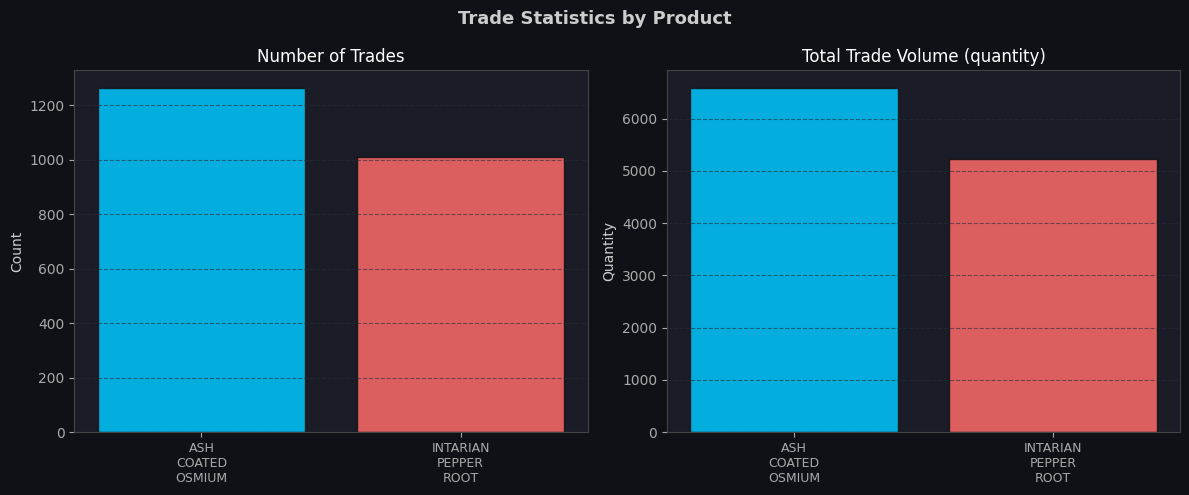

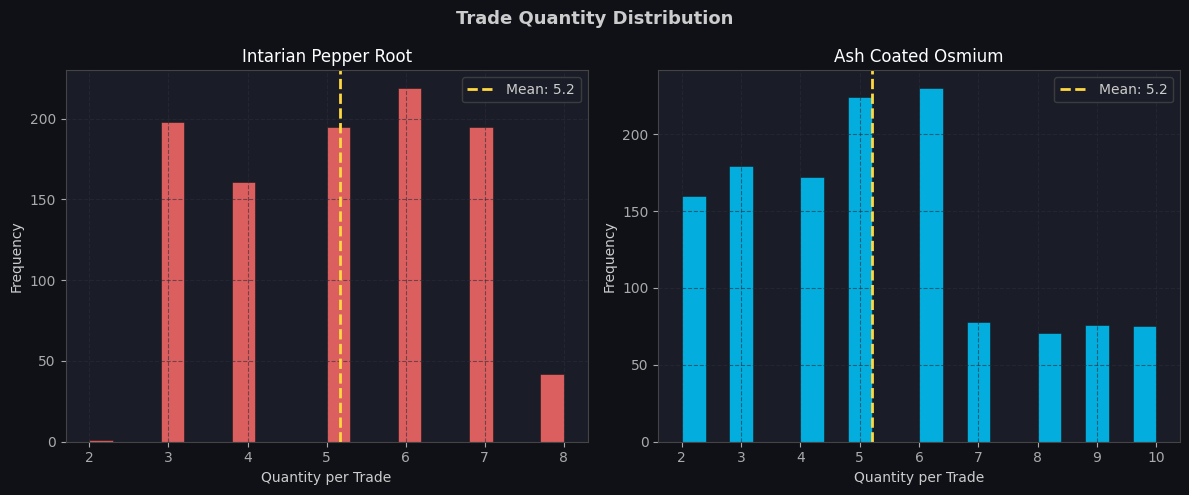

In [13]:
# Trades per product
trade_counts = trades.groupby('symbol').size().reset_index(name='count')
trade_vol = trades.groupby('symbol')['quantity'].sum().reset_index(name='total_qty')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Trade Statistics by Product', fontsize=13, fontweight='bold')

bar_colors = [COLORS[p] for p in trade_counts['symbol']]
axes[0].bar(trade_counts['symbol'], trade_counts['count'], color=bar_colors, alpha=0.85, edgecolor='#111')
axes[0].set_title('Number of Trades')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels([s.replace('_','\n') for s in trade_counts['symbol']], fontsize=9)
axes[0].grid(True, axis='y')

bar_colors2 = [COLORS[p] for p in trade_vol['symbol']]
axes[1].bar(trade_vol['symbol'], trade_vol['total_qty'], color=bar_colors2, alpha=0.85, edgecolor='#111')
axes[1].set_title('Total Trade Volume (quantity)')
axes[1].set_ylabel('Quantity')
axes[1].set_xticklabels([s.replace('_','\n') for s in trade_vol['symbol']], fontsize=9)
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.savefig('trade_stats.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

# Trade quantity distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Trade Quantity Distribution', fontsize=13, fontweight='bold')

for ax, product in zip(axes, PRODUCTS):
    sub = trades[trades['symbol'] == product]
    ax.hist(sub['quantity'], bins=20, color=COLORS[product], alpha=0.85, edgecolor='#111', linewidth=0.4)
    ax.set_title(product.replace('_',' ').title())
    ax.set_xlabel('Quantity per Trade')
    ax.set_ylabel('Frequency')
    ax.axvline(sub['quantity'].mean(), color='#ffd740', lw=2, linestyle='--',
               label=f'Mean: {sub["quantity"].mean():.1f}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig('trade_qty_dist.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 6. Trade Price vs Mid-Price

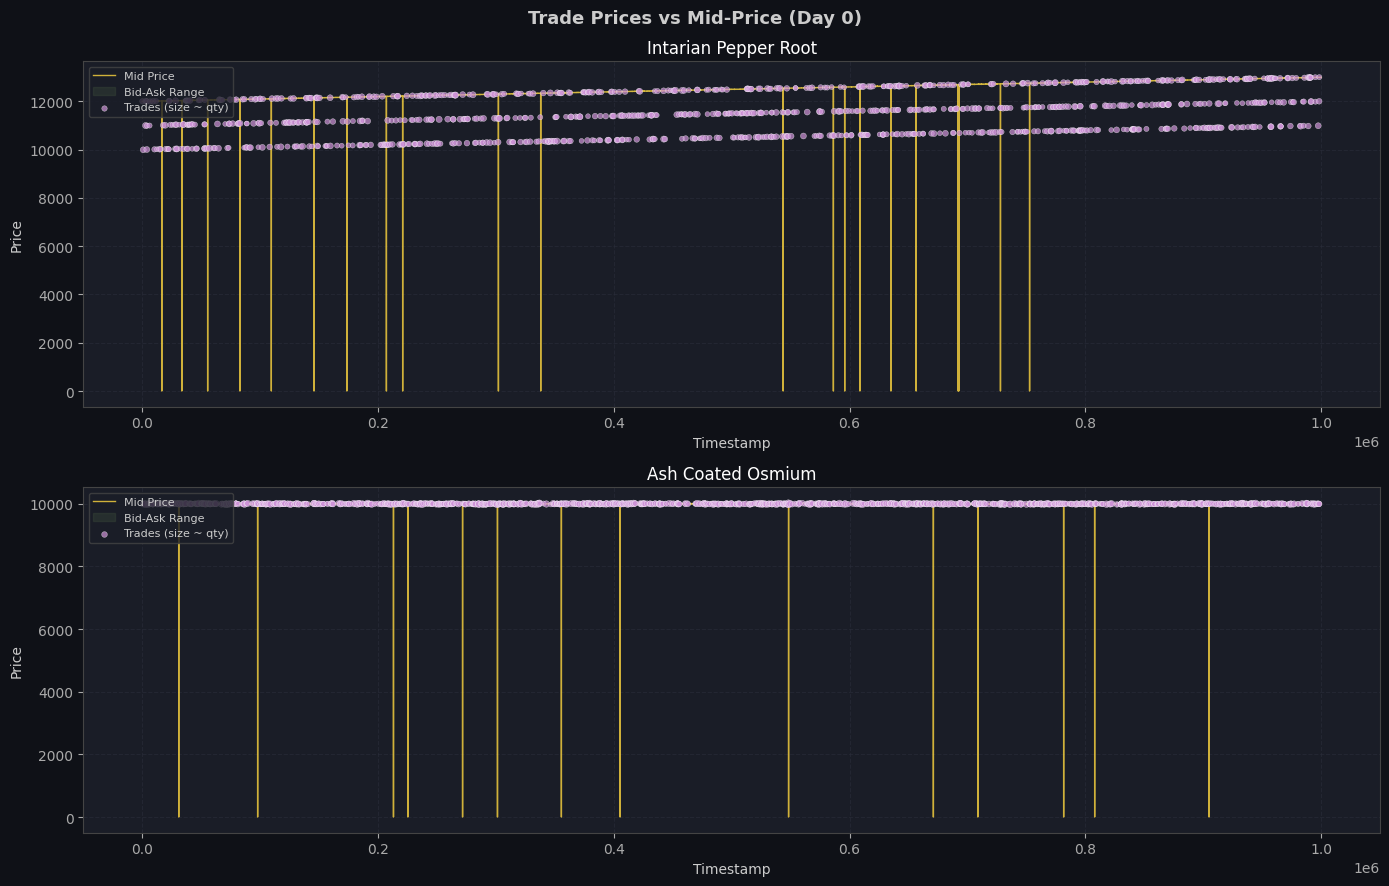

In [14]:
fig, axes = plt.subplots(len(PRODUCTS), 1, figsize=(14, 9))
fig.suptitle('Trade Prices vs Mid-Price (Day 0)', fontsize=13, fontweight='bold')

for ax, product in zip(axes, PRODUCTS):
    # Mid-price
    p_sub = prices[(prices['product'] == product) & (prices['day'] == 0)].sort_values('timestamp')
    ax.plot(p_sub['timestamp'], p_sub['mid_price'],
            color=COLORS['mid'], lw=1.0, alpha=0.8, label='Mid Price', zorder=2)
    
    # Best bid/ask
    ax.fill_between(p_sub['timestamp'], p_sub['bid_price_1'], p_sub['ask_price_1'],
                    color='#3a4a3a', alpha=0.4, label='Bid-Ask Range', zorder=1)
    
    # Trade prices
    t_sub = trades[trades['symbol'] == product].sort_values('timestamp')
    ax.scatter(t_sub['timestamp'], t_sub['price'],
               color=COLORS['trade'], s=t_sub['quantity']*1.5 + 8,
               alpha=0.7, zorder=3, label='Trades (size ~ qty)', edgecolors='#fff', linewidths=0.3)
    
    ax.set_title(product.replace('_', ' ').title())
    ax.set_ylabel('Price')
    ax.set_xlabel('Timestamp')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True)

plt.tight_layout()
plt.savefig('trade_vs_mid.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 7. Volatility & Rolling Statistics

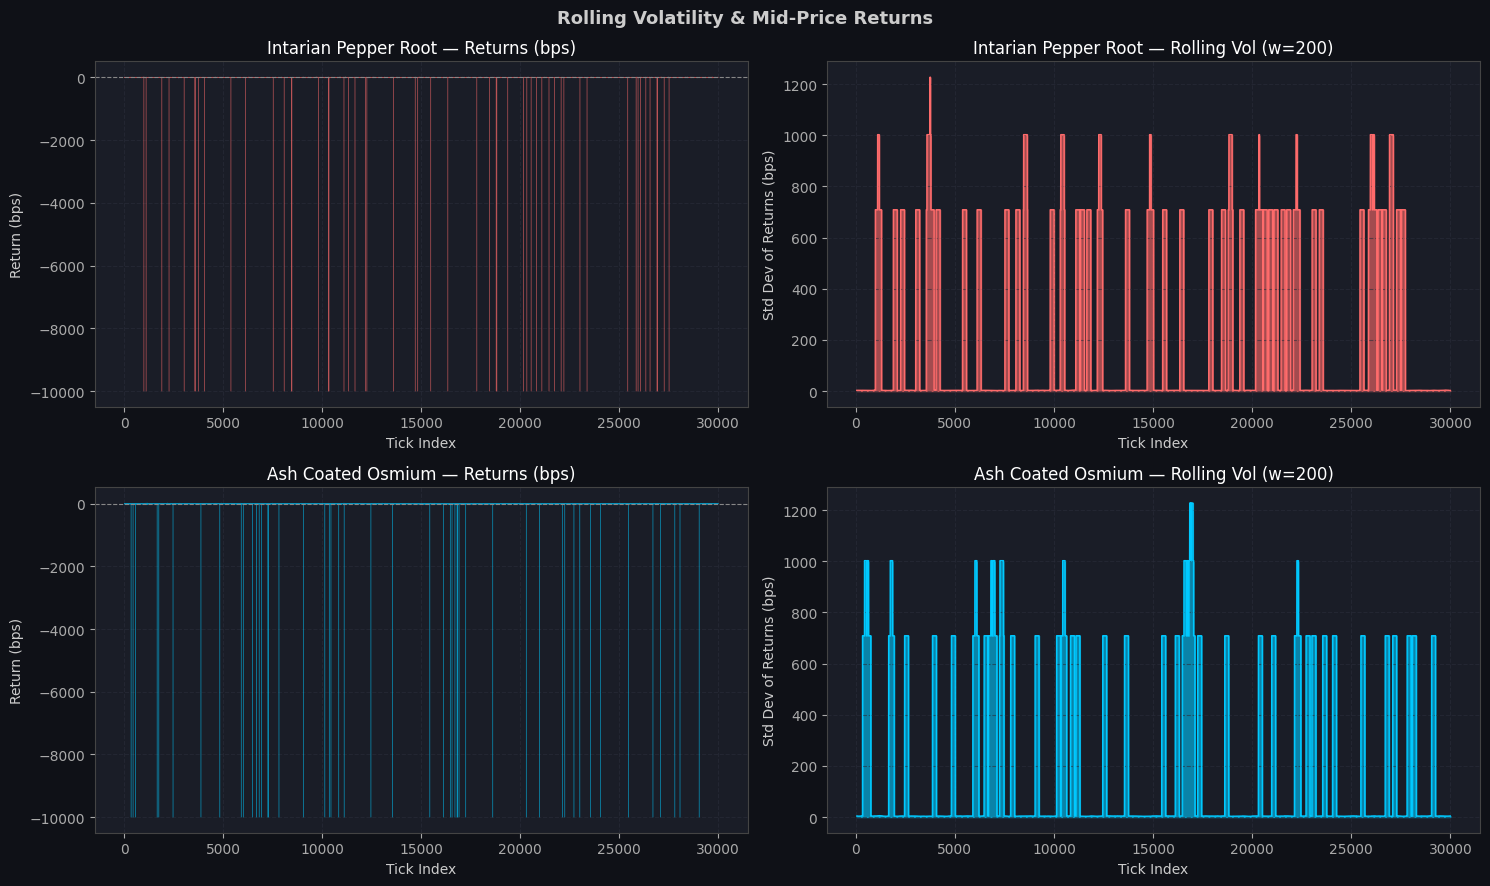

In [15]:
fig, axes = plt.subplots(len(PRODUCTS), 2, figsize=(15, 9))
fig.suptitle('Rolling Volatility & Mid-Price Returns', fontsize=13, fontweight='bold')

WINDOW = 200

for i, product in enumerate(PRODUCTS):
    sub = prices[prices['product'] == product].sort_values(['day','timestamp'])
    sub = sub.copy()
    sub['returns'] = sub['mid_price'].pct_change() * 10000  # in bps
    sub['rolling_vol'] = sub['returns'].rolling(WINDOW, min_periods=50).std()
    
    ax_ret = axes[i][0]
    ax_vol = axes[i][1]
    
    color = COLORS[product]
    
    # Returns
    ax_ret.plot(sub.reset_index().index, sub['returns'],
                color=color, lw=0.5, alpha=0.7)
    ax_ret.axhline(0, color='#888', lw=0.8, linestyle='--')
    ax_ret.set_title(f'{product.replace("_"," ").title()} — Returns (bps)')
    ax_ret.set_ylabel('Return (bps)')
    ax_ret.set_xlabel('Tick Index')
    ax_ret.grid(True)
    
    # Volatility
    ax_vol.fill_between(sub.reset_index().index, sub['rolling_vol'],
                        color=color, alpha=0.6)
    ax_vol.plot(sub.reset_index().index, sub['rolling_vol'],
                color=color, lw=1.0)
    ax_vol.set_title(f'{product.replace("_"," ").title()} — Rolling Vol (w={WINDOW})')
    ax_vol.set_ylabel('Std Dev of Returns (bps)')
    ax_vol.set_xlabel('Tick Index')
    ax_vol.grid(True)

plt.tight_layout()
plt.savefig('volatility.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 8. Summary Statistics

In [16]:
summary = []
for product in PRODUCTS:
    p = prices[prices['product'] == product]
    t = trades[trades['symbol'] == product]
    
    summary.append({
        'Product': product,
        'Mid Avg': round(p['mid_price'].mean(), 2),
        'Mid Min': p['mid_price'].min(),
        'Mid Max': p['mid_price'].max(),
        'Mid Std': round(p['mid_price'].std(), 2),
        'Avg Spread': round(p['spread'].mean(), 2),
        'Median Spread': p['spread'].median(),
        'Trade Count': len(t),
        'Total Qty': t['quantity'].sum(),
        'Avg Trade Qty': round(t['quantity'].mean(), 2),
        'Avg Trade Price': round(t['price'].mean(), 2),
    })

summary_df = pd.DataFrame(summary).set_index('Product').T
print(summary_df.to_string())

Product          INTARIAN_PEPPER_ROOT  ASH_COATED_OSMIUM
Mid Avg                      11479.19            9983.87
Mid Min                          0.00               0.00
Mid Max                      13007.00           10023.00
Mid Std                        993.18             403.87
Avg Spread                      13.05              16.18
Median Spread                   13.00              16.00
Trade Count                   1011.00            1265.00
Total Qty                     5230.00            6593.00
Avg Trade Qty                    5.17               5.21
Avg Trade Price              11495.94           10000.21


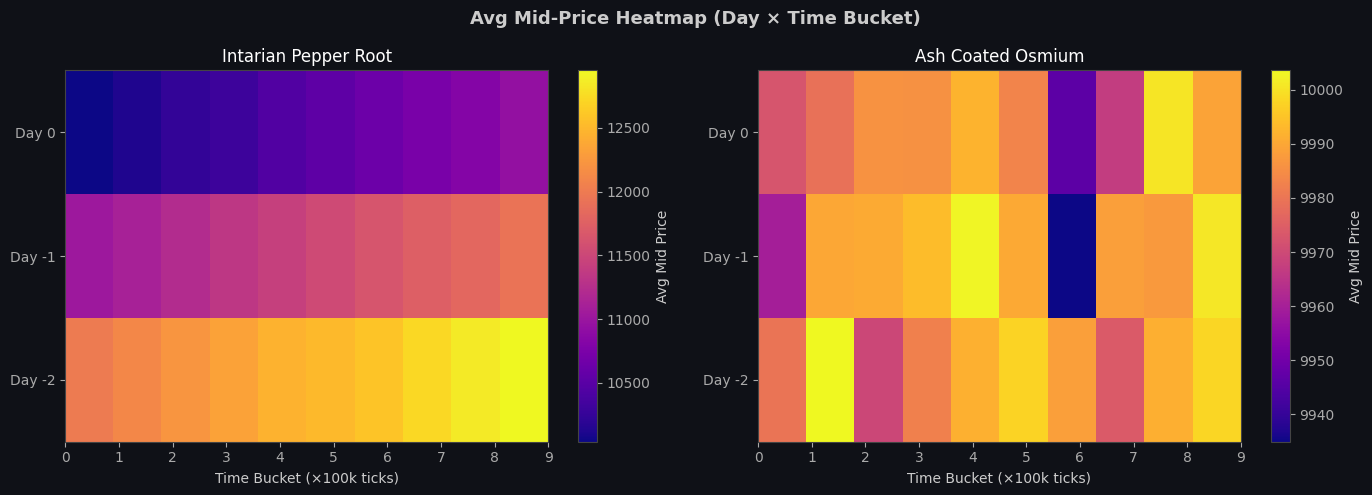

In [17]:
# Heatmap: avg mid price by day x hour-bucket
prices['hour_bucket'] = (prices['timestamp'] // 100000).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Avg Mid-Price Heatmap (Day × Time Bucket)', fontsize=13, fontweight='bold')

import matplotlib.colors as mcolors

for ax, product in zip(axes, PRODUCTS):
    sub = prices[prices['product'] == product]
    pivot = sub.pivot_table(values='mid_price', index='day', columns='hour_bucket', aggfunc='mean')
    
    im = ax.imshow(pivot.values, aspect='auto', cmap='plasma',
                   extent=[pivot.columns.min(), pivot.columns.max(),
                           pivot.index.min() - 0.5, pivot.index.max() + 0.5])
    plt.colorbar(im, ax=ax, label='Avg Mid Price')
    ax.set_yticks(pivot.index)
    ax.set_yticklabels([f'Day {d}' for d in pivot.index])
    ax.set_xlabel('Time Bucket (×100k ticks)')
    ax.set_title(product.replace('_', ' ').title())

plt.tight_layout()
plt.savefig('price_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()